In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [22]:
df = pd.read_csv('../data/athlete_events.csv')
regions = pd.read_csv('../data/noc_regions.csv')

In [23]:
df = pd.merge(df, regions, on='NOC', how='left')

In [40]:
df.head(5)

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal,region,Medal_Won
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,No Medal,China,0
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,No Medal,China,0
2,3,Gunnar Nielsen Aaby,M,24.0,175.0,71.0,Denmark,DEN,1920 Summer,1920,Summer,Antwerpen,Football,Football Men's Football,No Medal,Denmark,0
3,4,Edgar Lindenau Aabye,M,34.0,182.0,95.0,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold,Denmark,1
4,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,Netherlands,NED,1988 Winter,1988,Winter,Calgary,Speed Skating,Speed Skating Women's 500 metres,No Medal,Netherlands,0


In [25]:
print(df.shape)
print(df.columns.tolist())
print(df.info())
print(df.describe())

(271116, 17)
['ID', 'Name', 'Sex', 'Age', 'Height', 'Weight', 'Team', 'NOC', 'Games', 'Year', 'Season', 'City', 'Sport', 'Event', 'Medal', 'region', 'notes']
<class 'pandas.DataFrame'>
RangeIndex: 271116 entries, 0 to 271115
Data columns (total 17 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   ID      271116 non-null  int64  
 1   Name    271116 non-null  str    
 2   Sex     271116 non-null  str    
 3   Age     261642 non-null  float64
 4   Height  210945 non-null  float64
 5   Weight  208241 non-null  float64
 6   Team    271116 non-null  str    
 7   NOC     271116 non-null  str    
 8   Games   271116 non-null  str    
 9   Year    271116 non-null  int64  
 10  Season  271116 non-null  str    
 11  City    271116 non-null  str    
 12  Sport   271116 non-null  str    
 13  Event   271116 non-null  str    
 14  Medal   39783 non-null   str    
 15  region  270746 non-null  str    
 16  notes   5039 non-null    str    
dtypes: float64(3), 

In [26]:
print(df.isnull().sum())

ID             0
Name           0
Sex            0
Age         9474
Height     60171
Weight     62875
Team           0
NOC            0
Games          0
Year           0
Season         0
City           0
Sport          0
Event          0
Medal     231333
region       370
notes     266077
dtype: int64


In [27]:
print("Sports:", df['Sport'].nunique())
print("Countries:", df['region'].nunique())
print("Years:", df['Year'].min(), "to", df['Year'].max())
print("Athletes:", df['Name'].nunique())

Sports: 66
Countries: 205
Years: 1896 to 2016
Athletes: 134732


In [28]:
df.drop(columns=['notes'], inplace=True)

In [29]:
df['Medal'] = df['Medal'].fillna('No Medal')

In [30]:
print(df['Medal'].value_counts())
print(df['Medal'].isnull().sum())

Medal
No Medal    231333
Gold         13372
Bronze       13295
Silver       13116
Name: count, dtype: int64
0


In [31]:
df['Medal_Won'] = df['Medal'].apply(lambda x: 0 if x == 'No Medal' else 1)

In [32]:
df['Age'] = df.groupby('Sport')['Age'].transform(
    lambda x: x.fillna(x.median())
)

In [33]:
df['Height'] = df.groupby('Sport')['Height'].transform(
    lambda x: x.fillna(x.median())
)

In [34]:
df['Weight'] = df.groupby('Sport')['Weight'].transform(
    lambda x: x.fillna(x.median())
)

In [35]:
df.dropna(subset=['region'], inplace=True)

In [36]:
df['Height'] = df['Height'].fillna(df['Height'].median())
df['Weight'] = df['Weight'].fillna(df['Weight'].median())

In [37]:
print("Shape after cleaning:", df.shape)
print("\nMissing values remaining:")
print(df.isnull().sum())
print("\nMedal_Won value counts:")
print(df['Medal_Won'].value_counts())

Shape after cleaning: (270746, 17)

Missing values remaining:
ID           0
Name         0
Sex          0
Age          0
Height       0
Weight       0
Team         0
NOC          0
Games        0
Year         0
Season       0
City         0
Sport        0
Event        0
Medal        0
region       0
Medal_Won    0
dtype: int64

Medal_Won value counts:
Medal_Won
0    230972
1     39774
Name: count, dtype: int64


In [38]:
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

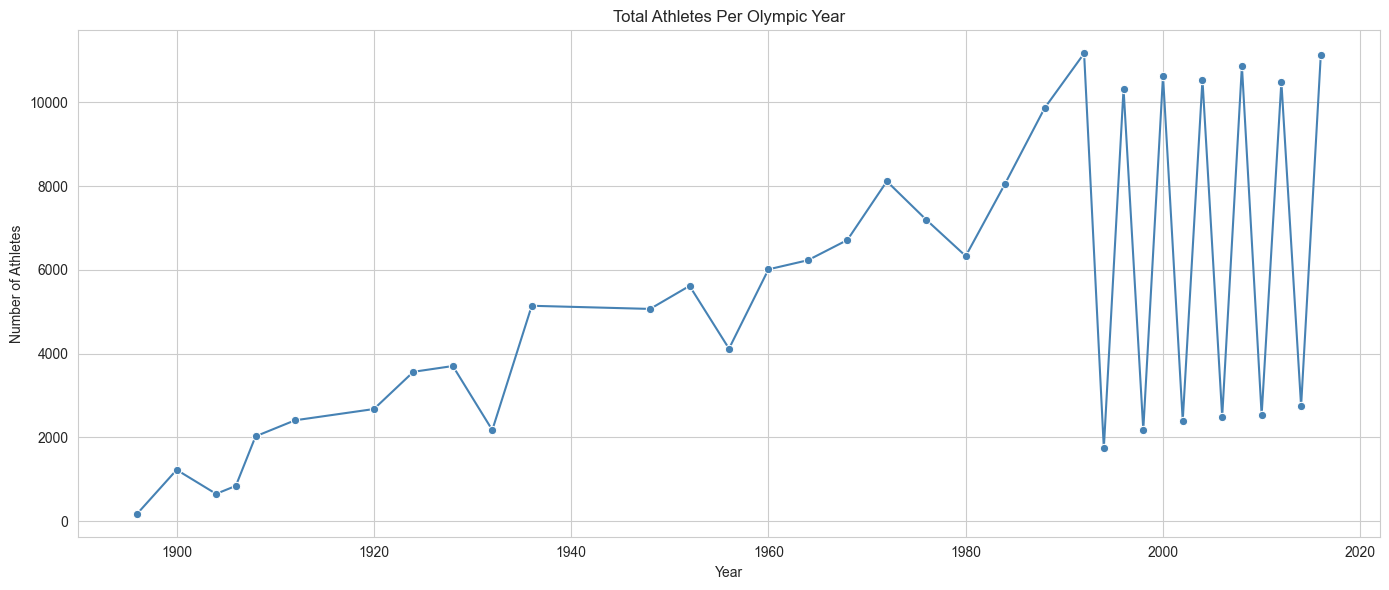

In [39]:
athletes_per_year = df.groupby('Year')['ID'].nunique().reset_index()
athletes_per_year.columns = ['Year', 'Athletes']

plt.figure(figsize=(14, 6))
sns.lineplot(data=athletes_per_year, x='Year', y='Athletes', marker='o', color='steelblue')
plt.title('Total Athletes Per Olympic Year')
plt.xlabel('Year')
plt.ylabel('Number of Athletes')
plt.tight_layout()
plt.show()

In [43]:
df.groupby('Year')['ID'].nunique()

Year
1896      176
1900     1224
1904      650
1906      841
1908     2024
1912     2407
1920     2676
1924     3565
1928     3703
1932     2174
1936     5142
1948     5067
1952     5617
1956     4118
1960     6012
1964     6230
1968     6713
1972     8115
1976     7196
1980     6330
1984     8062
1988     9865
1992    11169
1994     1738
1996    10325
1998     2179
2000    10633
2002     2399
2004    10541
2006     2494
2008    10871
2010     2536
2012    10491
2014     2745
2016    11143
Name: ID, dtype: int64

C:\Users\DELL\AppData\Local\Temp\ipykernel_18036\2998956168.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=season_counts, x='Season', y='ID', palette=['#378ADD', '#B5D4F4'])


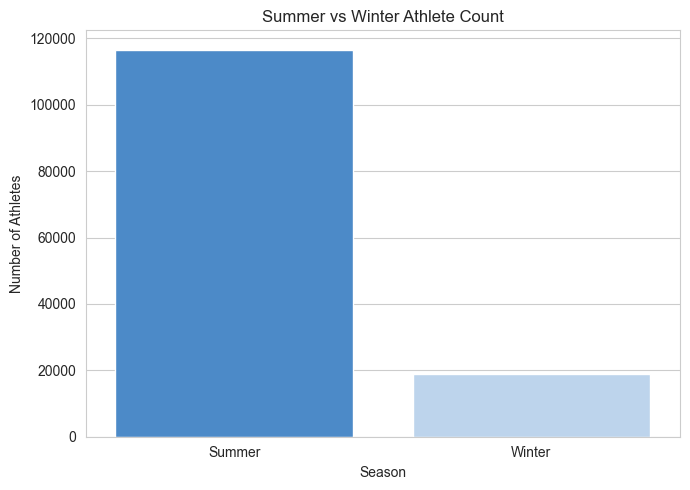

In [44]:
season_counts = df.groupby('Season')['ID'].nunique().reset_index()

plt.figure(figsize=(7, 5))
sns.barplot(data=season_counts, x='Season', y='ID', palette=['#378ADD', '#B5D4F4'])
plt.title('Summer vs Winter Athlete Count')
plt.xlabel('Season')
plt.ylabel('Number of Athletes')
plt.tight_layout()
plt.show()

C:\Users\DELL\AppData\Local\Temp\ipykernel_18036\3997326613.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=medal_counts, x='Medal', y='Count', palette=colors)


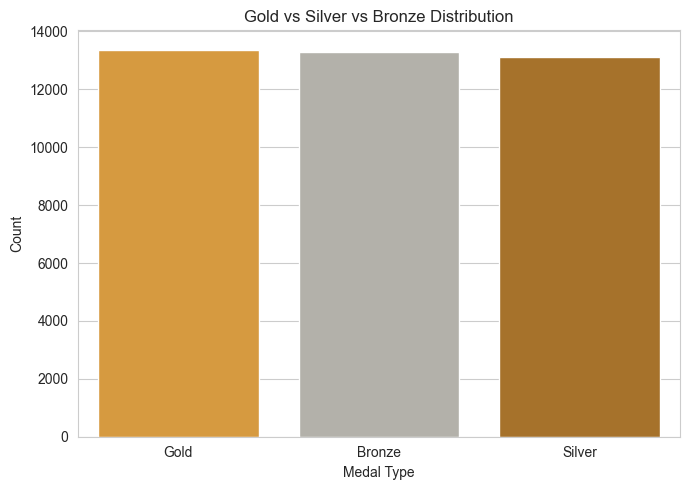

In [45]:
medal_counts = df[df['Medal'] != 'No Medal']['Medal'].value_counts().reset_index()
medal_counts.columns = ['Medal', 'Count']

plt.figure(figsize=(7, 5))
colors = ['#EF9F27', '#B4B2A9', '#BA7517']
sns.barplot(data=medal_counts, x='Medal', y='Count', palette=colors)
plt.title('Gold vs Silver vs Bronze Distribution')
plt.xlabel('Medal Type')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# Add new markdown cell
# ## 4.2 Country Analysis

C:\Users\DELL\AppData\Local\Temp\ipykernel_18036\3003602218.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_countries, x='Medals', y='Country', palette='Blues_r')


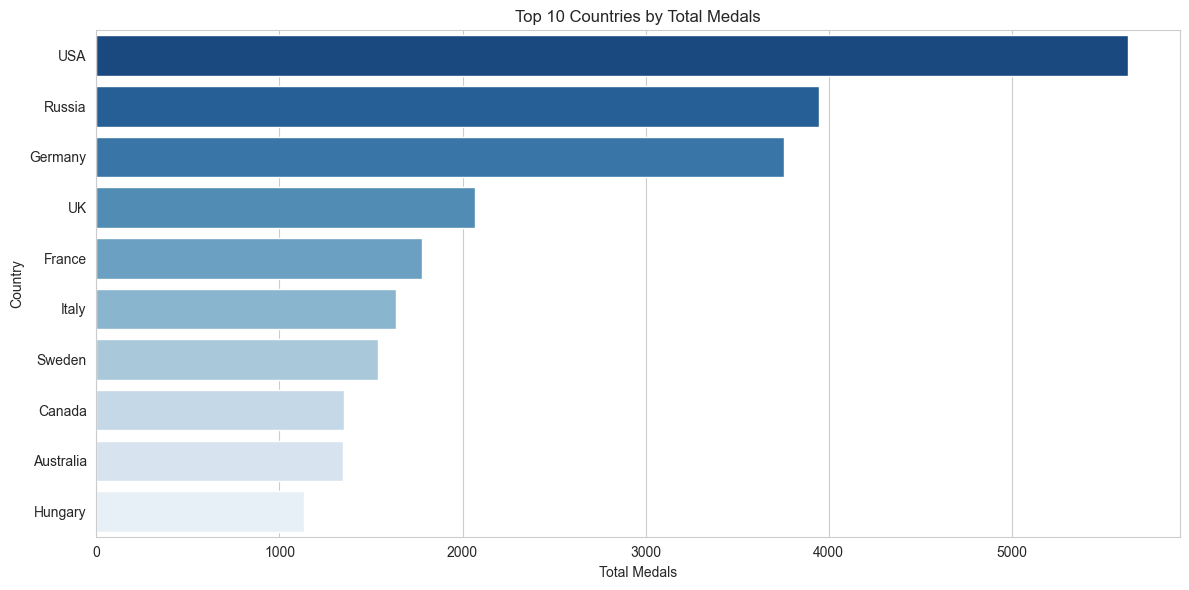

In [46]:
top_countries = df[df['Medal'] != 'No Medal'].groupby('region')['Medal'].count().reset_index()
top_countries.columns = ['Country', 'Medals']
top_countries = top_countries.sort_values('Medals', ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(data=top_countries, x='Medals', y='Country', palette='Blues_r')
plt.title('Top 10 Countries by Total Medals')
plt.xlabel('Total Medals')
plt.ylabel('Country')
plt.tight_layout()
plt.show()

In [47]:
top_countries.sort_values('Medals', ascending=False).head(10)

,Country,Medals
125,USA,5637
100,Russia,3947
41,Germany,3756
124,UK,2068
38,France,1777
57,Italy,1637
112,Sweden,1536
18,Canada,1352
4,Australia,1349
48,Hungary,1135


C:\Users\DELL\AppData\Local\Temp\ipykernel_18036\4179239210.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=gold_countries, x='Gold Medals', y='Country', palette='YlOrBr')


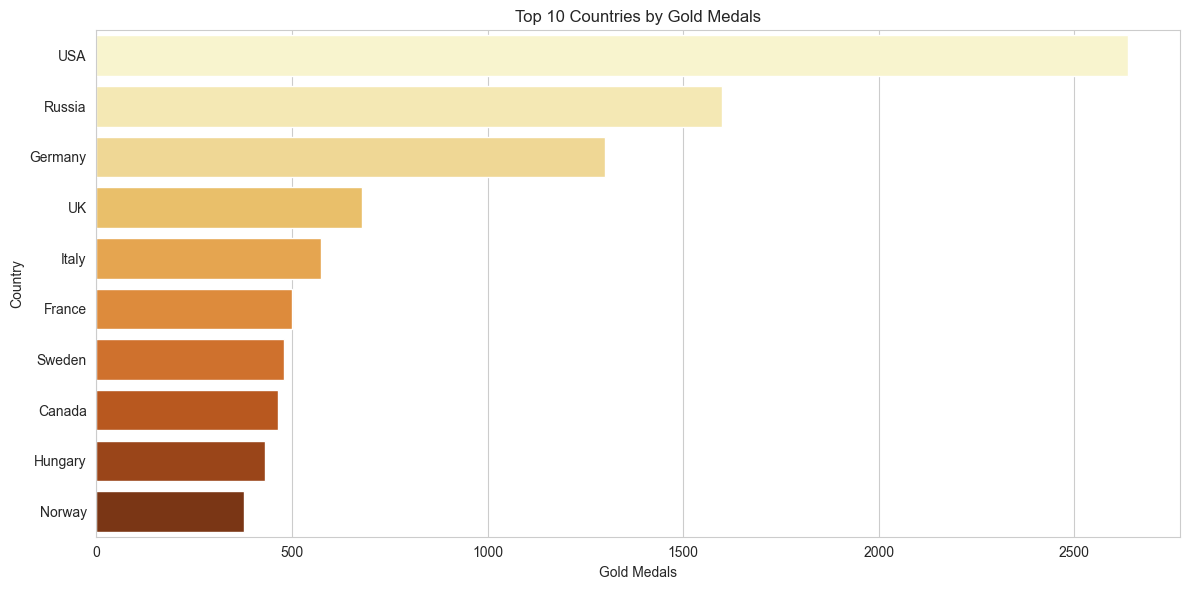

In [48]:
gold_countries = df[df['Medal'] == 'Gold'].groupby('region')['Medal'].count().reset_index()
gold_countries.columns = ['Country', 'Gold Medals']
gold_countries = gold_countries.sort_values('Gold Medals', ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(data=gold_countries, x='Gold Medals', y='Country', palette='YlOrBr')
plt.title('Top 10 Countries by Gold Medals')
plt.xlabel('Gold Medals')
plt.ylabel('Country')
plt.tight_layout()
plt.show()

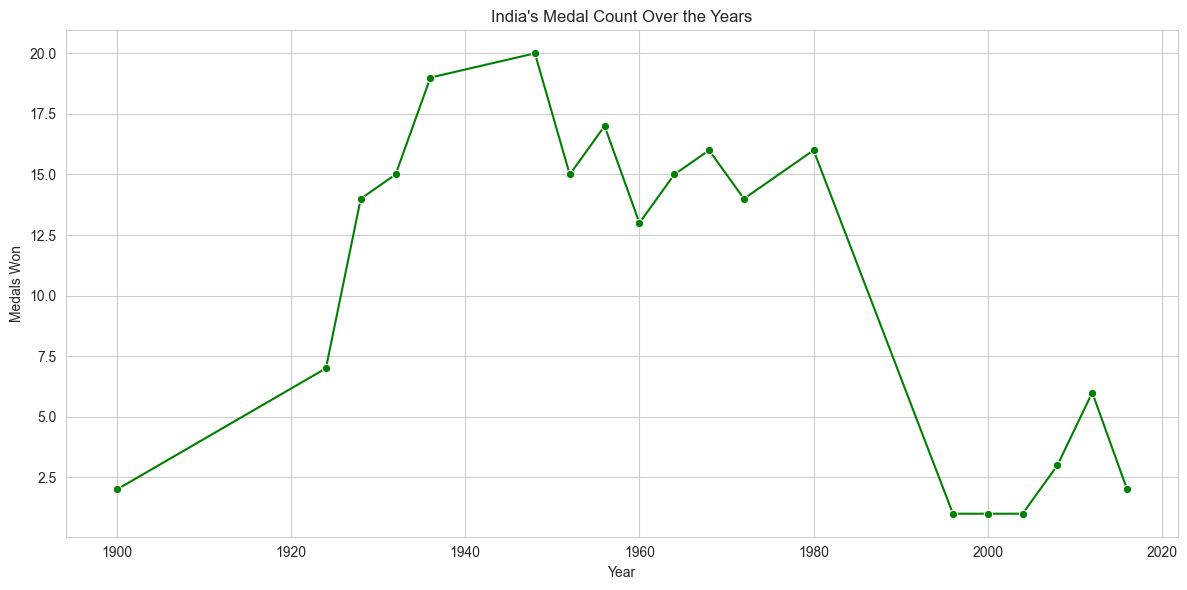

In [49]:
india = df[(df['region'] == 'India') & (df['Medal'] != 'No Medal')]
india_trend = india.groupby('Year')['Medal'].count().reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(data=india_trend, x='Year', y='Medal', marker='o', color='green')
plt.title("India's Medal Count Over the Years")
plt.xlabel('Year')
plt.ylabel('Medals Won')
plt.tight_layout()
plt.show()

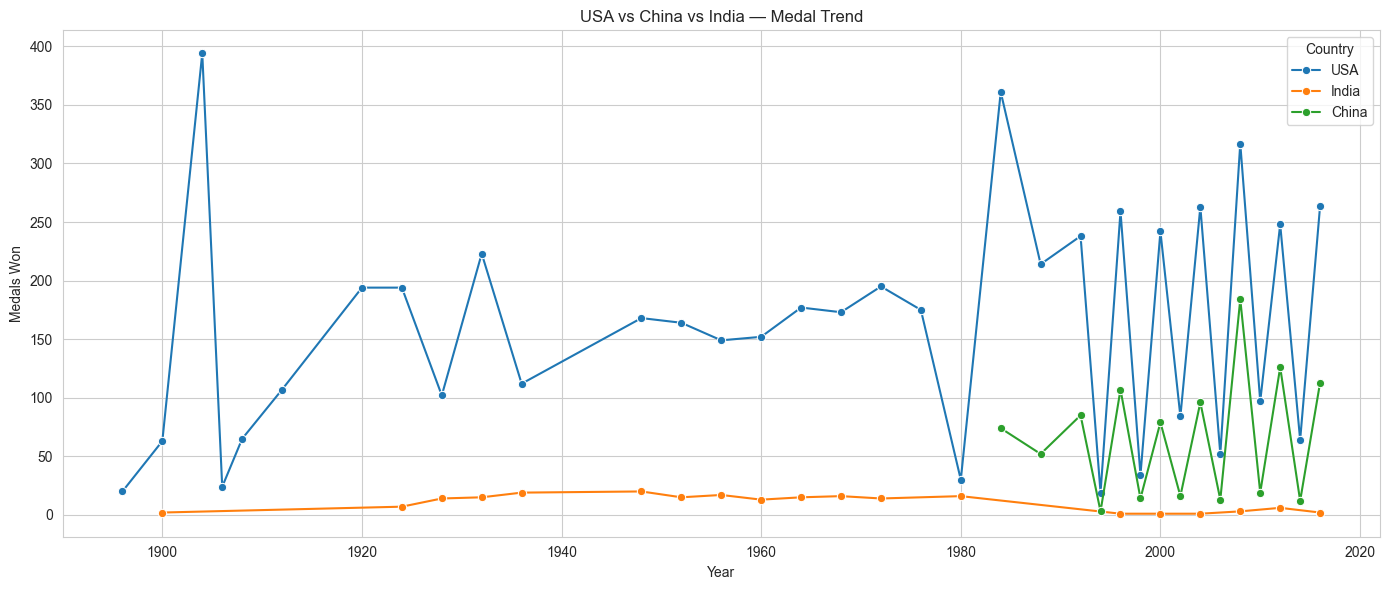

In [50]:
countries = ['USA', 'China', 'India']
country_trend = df[(df['region'].isin(countries)) & (df['Medal'] != 'No Medal')]
country_trend = country_trend.groupby(['Year', 'region'])['Medal'].count().reset_index()

plt.figure(figsize=(14, 6))
sns.lineplot(data=country_trend, x='Year', y='Medal', hue='region', marker='o')
plt.title('USA vs China vs India — Medal Trend')
plt.xlabel('Year')
plt.ylabel('Medals Won')
plt.legend(title='Country')
plt.tight_layout()
plt.show()